<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_5d_nonpotential_stochastic_parameter_map_dtb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5D constrained non-potential Cournot: evolving neural solution map

Comparison copy of [the fixed-network particle-update notebook](https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_5d_nonpotential_stochastic_mlp_dtb.ipynb).
The controls, initial samples and scores, random MLP initialization, selected
parameter indices, SVD solver, Euler score/log-density scheme, EM noise stream,
and plots are preserved. Here the solution is evaluated as $X_k(z)=T_{\theta_k}(z)$
after every parameter step. The source notebook is unchanged.

## Five-player game setup

For player $i$, let $r_i=\sum_{j\ne i}x_j$. With $b=1$ and $\mu=2$,
nonnegative production gives

$$
\operatorname{BR}_i(x)=\max\{2r_i(1-r_i),0\},
\qquad
b_i(x)=2\bigl[\operatorname{BR}_i(x)-x_i\bigr].
$$

The stochastic implementation uses five independent noise components of
amplitude $0.1$:

$$
\sigma_1=\cdots=\sigma_5=0.1,
\qquad D=0.01I_5.
$$

The initial distribution is uniform on $[0,1]^5$. The thesis reports seven
reference equilibria: the origin, $(7/32)^5$, and the five permutations of
$(0,5/18,5/18,5/18,5/18)$. It reports all seven as unstable and notes that
the list may be incomplete.


## Block 0 — Shared repository setup

This notebook reuses `ResidualMLPMap`, `game_dtb_basis_matrices`, and
`map_at` from `run_game_dtb.py`; `count_trainable` from `network.py`;
and `flat_params` plus `jform_solve` from `dtb.py`. Score evolution and
plotting use the same shared `utility.py`. A local helper below converts
reference-coordinate tangent derivatives to physical-coordinate derivatives.


In [1]:
# BLOCK 0 — Locate the shared modules locally or clone the requested branch in Colab.
from pathlib import Path
import math
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.func import jacrev, jvp, vmap
from IPython.display import Markdown, display

MODULE_FILES = ('run_game_dtb.py', 'network.py', 'dtb.py', 'utility.py')
EXPERIMENT_DIR = next(
    (
        folder
        for folder in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
        if all((folder / name).is_file() for name in MODULE_FILES)
    ),
    None,
)

if EXPERIMENT_DIR is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2 directory.')
    repo = Path('/content/dtb-colab-experiments')
    if not (repo / '.git').exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    else:
        subprocess.run(['git', '-C', str(repo), 'checkout', 'codex/game-dynamics-dtb'], check=True)
        subprocess.run(['git', '-C', str(repo), 'pull', '--ff-only'], check=True)
    EXPERIMENT_DIR = repo / 'DTB_Game_Ver2'

# Import the existing DTB, network, and map primitives requested for reuse.
sys.path.insert(0, str(EXPERIMENT_DIR.resolve()))
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices, map_at
from network import count_trainable
from dtb import device, flat_params, jform_solve
from importlib import reload
import utility as stochastic_utility

stochastic_utility = reload(stochastic_utility)
from utility import (
    create_run_directory,
    diagnostics_markdown,
    euler_score_update,
    plot_dtb_em_snapshots,
    plot_tangent_diagnostics,
    sample_initial_with_score,
    save_run_data,
    sliced_wasserstein_distance,
)

print('Shared module directory:', EXPERIMENT_DIR)

Shared module directory: /private/tmp/dtb-cournot-refit-publish-20260907/DTB_Game_Ver2


## Block 1 — Game and experiment controls

All numerical, neural-network, stochastic, saving, and visualization
parameters are editable below. The complete realized configuration is
printed after the particles and tangent basis have been initialized.

In [2]:
# BLOCK 1 — Define the five-player game and every editable experiment control.
SAVE_RUN = False  # True creates a uniquely named folder under saved_runs/.
SEED = 2026
EM_SEED = SEED + 10_000

DIM = 5
N_PARTICLES = 2000
H = 0.005
T_FINAL = 0.16
N_STEPS = round(T_FINAL / H)
SNAPSHOT_TIMES = (0.0, 0.12, 0.14, 0.16)

# Independent stochastic forcing is applied to all five player quantities.
NOISE_STD = (0.1, 0.1, 0.1, 0.1, 0.1)

# "uniform" matches the paper's samples and uses the exact interior score q_0=0.
# "gaussian" and "smoothed_uniform" provide globally smooth analytical scores.
INITIAL_LAW = 'uniform'
GAUSSIAN_MEAN = 0.5
GAUSSIAN_STD = 0.15
UNIFORM_SMOOTHING_STD = 0.02

NN_CHOICE = 'mlp'
NN_ACTIVATION = 'tanh'  # Smooth activation is required by grad(div(u)).
MLP_WIDTH = 32
MLP_DEPTH = 4
BASIS_SIZE = 128
SVD_RTOL = 1e-3
SVD_METHOD = 'svd_gpu'
JACOBIAN_CHUNK = 64
DERIVATIVE_CHUNK = 16
PRINT_EVERY = 4          # full numerical diagnostics
PRINT_STEP_TIMING = True # step time, elapsed time, running mean, and ETA every step

DTYPE = torch.float32
DEVICE = device()
COURNOT_B = 1.0
COURNOT_MU = 2.0
COORDINATE_PAIRS = ((1, 2), (3, 4))

def game_velocity(x):
    """Five-player constrained non-potential Cournot best-response field."""
    if x.shape[-1] != DIM:
        raise ValueError(f'Expected states with last dimension {DIM}.')
    rivals = x.sum(dim=-1, keepdim=True) - x
    best_response = (COURNOT_MU * rivals * (1.0 - rivals)).clamp_min(0.0)
    return 2.0 * COURNOT_B * (best_response - x)

known_points = [torch.zeros(DIM, device=DEVICE, dtype=DTYPE)]
known_points.append(torch.full((DIM,), 7/32, device=DEVICE, dtype=DTYPE))
for zero_player in range(DIM):
    point = torch.full((DIM,), 5/18, device=DEVICE, dtype=DTYPE)
    point[zero_player] = 0.0
    known_points.append(point)
KNOWN_EQUILIBRIA = torch.stack(known_points)
STABLE_MASK = np.zeros(len(KNOWN_EQUILIBRIA), dtype=bool)

## Block 2 — Particle, score, and neural map initialization

Keep the initial labels $z_i=x_i^0$ fixed. Use the same random MLP $f_\theta$
and initial weights $\theta_0$ as the source notebook, with the solution map

$$
T_\theta(z)=z+f_\theta(z)-f_{\theta_0}(z).
$$

The frozen subtraction makes $T_{\theta_0}(z)=z$ exactly, preserving both the
initial cloud and the original random tangent basis. It is part of the map
definition, not a refit. The same selected parameter indices $S$ are kept
throughout; the tangent basis changes as $\theta_k$ changes.


In [3]:
# BLOCK 2 — Initialize the same particles, scores, and random MLP.
if NN_ACTIVATION not in {'tanh', 'gelu', 'silu'}:
    raise ValueError('Score evolution requires a twice-differentiable activation.')
if not np.isclose(N_STEPS * H, T_FINAL):
    raise ValueError('T_FINAL must be an integer multiple of H.')
if len(NOISE_STD) != DIM:
    raise ValueError('NOISE_STD needs one independent amplitude per player.')

# Seed the neural network and use separate recorded streams for particles and EM noise.
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
generator_device = DEVICE.type if DEVICE.type == 'cuda' else 'cpu'
initial_generator = torch.Generator(device=generator_device).manual_seed(SEED)
em_generator = torch.Generator(device=generator_device).manual_seed(EM_SEED)

# Attach the analytical initial score to every persistent particle label.
x_0, q_0, log_density_0 = sample_initial_with_score(
    N_PARTICLES,
    DIM,
    law=INITIAL_LAW,
    device=DEVICE,
    dtype=DTYPE,
    generator=initial_generator,
    gaussian_mean=GAUSSIAN_MEAN,
    gaussian_std=GAUSSIAN_STD,
    smoothing_std=UNIFORM_SMOOTHING_STD,
)
z = x_0.clone()  # Persistent reference labels for T_theta.
x_k = x_0.clone()
q_k = q_0.clone()
log_density_k = log_density_0.clone()
em_k = x_0.clone()  # The baseline starts from exactly the same point cloud.

# Preserve the source initialization; flat theta_k supplies the evolving weights.
mlp = ResidualMLPMap(
    dim=DIM,
    width=MLP_WIDTH,
    depth=MLP_DEPTH,
    activation=NN_ACTIVATION,
    dtype=DTYPE,
    zero_init_output=False,
).net.to(DEVICE)
N_PARAMETERS = count_trainable(mlp)
theta_0, structure, _ = flat_params(mlp)
theta_k = theta_0.clone()
mlp.requires_grad_(False)  # map_at substitutes theta_k without copying into the module.

# Keep the same selected parameter indices; their tangent columns evolve with theta_k.
if not isinstance(BASIS_SIZE, int) or not 1 <= BASIS_SIZE <= N_PARAMETERS:
    raise ValueError(f'BASIS_SIZE must be in [1, {N_PARAMETERS}].')
basis_generator = torch.Generator(device='cpu').manual_seed(SEED)
selected = torch.randperm(N_PARAMETERS, generator=basis_generator)[:BASIS_SIZE]
selected = selected.sort().values.to(DEVICE)

# Sigma is the SDE amplitude; D=Sigma Sigma^T is the Fokker--Planck covariance.
sigma = torch.tensor(NOISE_STD, device=DEVICE, dtype=DTYPE)
diffusion = torch.diag(sigma.square())

# Verify that every plotted analytical reference is stationary for this game field.
equilibrium_residual = float(game_velocity(KNOWN_EQUILIBRIA).norm(dim=1).max())
if equilibrium_residual > 2e-5:
    raise ValueError(f'An equilibrium reference has drift residual {equilibrium_residual:.3e}.')

# Convert requested physical times to exact stored state indices.
snapshot_steps = [round(value / H) for value in SNAPSHOT_TIMES]
if any(not np.isclose(step * H, value) for step, value in zip(snapshot_steps, SNAPSHOT_TIMES)):
    raise ValueError('Every snapshot time must lie on the time grid.')

# Save every experiment setting and the exact selected parameter indices.
CONFIG = {
    'update_scheme': 'parameter_map',
    'solution_map': 'z + f_theta(z) - f_theta_initial(z)',
    'game_dimension': DIM,
    'particles': N_PARTICLES,
    'step_size': H,
    'steps': N_STEPS,
    'final_time': T_FINAL,
    'snapshot_times': list(SNAPSHOT_TIMES),
    'noise_std': list(NOISE_STD),
    'diffusion_diagonal': sigma.square().detach().cpu().tolist(),
    'maximum_equilibrium_residual': equilibrium_residual,
    'initial_law': INITIAL_LAW,
    'gaussian_mean': GAUSSIAN_MEAN,
    'gaussian_std': GAUSSIAN_STD,
    'uniform_smoothing_std': UNIFORM_SMOOTHING_STD,
    'network': NN_CHOICE,
    'activation': NN_ACTIVATION,
    'width': MLP_WIDTH,
    'depth': MLP_DEPTH,
    'trainable_parameters': N_PARAMETERS,
    'basis_size': BASIS_SIZE,
    'selected_parameter_indices': selected.detach().cpu().tolist(),
    'svd_rtol': SVD_RTOL,
    'svd_method': SVD_METHOD,
    'jacobian_chunk': JACOBIAN_CHUNK,
    'derivative_chunk': DERIVATIVE_CHUNK,
    'print_every': PRINT_EVERY,
    'print_step_timing': PRINT_STEP_TIMING,
    'coordinate_pairs': [list(pair) for pair in COORDINATE_PAIRS],
    'seed': SEED,
    'em_seed': EM_SEED,
    'device': str(DEVICE),
    'dtype': str(DTYPE),
    'save_run': SAVE_RUN,
    'output_root': str(EXPERIMENT_DIR / 'saved_runs'),
}

# Print a complete, readable statement immediately after initialization.
print('=' * 76)
print(f'STOCHASTIC {DIM}D COURNOT NEURAL-DTB: PARAMETER SOLUTION MAP')
print('=' * 76)
print(f'Game/player dimension: d={DIM}; b={COURNOT_B}; mu={COURNOT_MU}')
print(f'Particles and time: N={N_PARTICLES}; h={H}; K={N_STEPS}; T={T_FINAL}')
print(f'Snapshot times: {SNAPSHOT_TIMES}')
print(f'Noise amplitudes sigma_i: {NOISE_STD}')
print(f'Diffusion covariance diagonal D_ii: {CONFIG["diffusion_diagonal"]}')
print(f'Maximum equilibrium drift residual: {equilibrium_residual:.3e}')
print(f'Initial law: {INITIAL_LAW}; Gaussian mean/std={GAUSSIAN_MEAN}/{GAUSSIAN_STD}; smoothing={UNIFORM_SMOOTHING_STD}')
print(f'Initial score RMS: {float(q_0.square().sum(dim=1).mean().sqrt()):.6g}')
print(f'Network: {NN_CHOICE}; {DIM} -> ' + ' -> '.join([str(MLP_WIDTH)] * MLP_DEPTH) + f' -> {DIM}')
print(f'Activation/depth/width: {NN_ACTIVATION}/{MLP_DEPTH}/{MLP_WIDTH}')
print(f'Trainable parameters: {N_PARAMETERS}')
print(f'Selected tangent size: {BASIS_SIZE}; selection seed={SEED}')
print(f'Selected flat-parameter indices: {CONFIG["selected_parameter_indices"]}')
print(f'Projection solver: {SVD_METHOD}; relative SVD tolerance={SVD_RTOL}')
print(f'Jacobian/derivative chunks: {JACOBIAN_CHUNK}/{DERIVATIVE_CHUNK}')
print(f'Per-step timer: {PRINT_STEP_TIMING}; full diagnostics every {PRINT_EVERY} step(s)')
print(f'Device/dtype: {DEVICE}/{DTYPE}; EM seed={EM_SEED}')
print(f'Coordinate planes: {COORDINATE_PAIRS}')
print(f'Save run: {SAVE_RUN}; output root={CONFIG["output_root"]}')
print('Reported reference equilibria:')
for index, point in enumerate(KNOWN_EQUILIBRIA.detach().cpu().numpy()):
    stability = 'stable' if STABLE_MASK[index] else 'unstable'
    print(f'  E_{index} = {np.array2string(point, precision=8)} [{stability}]')
if INITIAL_LAW == 'uniform':
    print('Uniform-score note: q_0=0 is the exact interior score; the boundary score is singular.')
print('=' * 76)

STOCHASTIC 5D COURNOT NEURAL-DTB: PARAMETER SOLUTION MAP
Game/player dimension: d=5; b=1.0; mu=2.0
Particles and time: N=2000; h=0.005; K=32; T=0.16
Snapshot times: (0.0, 0.12, 0.14, 0.16)
Noise amplitudes sigma_i: (0.1, 0.1, 0.1, 0.1, 0.1)
Diffusion covariance diagonal D_ii: [0.010000000707805157, 0.010000000707805157, 0.010000000707805157, 0.010000000707805157, 0.010000000707805157]
Maximum equilibrium drift residual: 2.384e-07
Initial law: uniform; Gaussian mean/std=0.5/0.15; smoothing=0.02
Initial score RMS: 0
Network: mlp; 5 -> 32 -> 32 -> 32 -> 32 -> 5
Activation/depth/width: tanh/4/32
Trainable parameters: 3525
Selected tangent size: 128; selection seed=2026
Selected flat-parameter indices: [5, 55, 56, 62, 73, 137, 178, 184, 195, 209, 210, 274, 285, 344, 368, 475, 508, 509, 525, 575, 593, 622, 659, 670, 692, 763, 786, 803, 817, 831, 854, 899, 917, 925, 945, 992, 1025, 1138, 1156, 1260, 1283, 1289, 1323, 1329, 1349, 1351, 1358, 1364, 1380, 1403, 1426, 1439, 1450, 1521, 1537, 1641

## Block 3 — Parameter update and neural solution map

At fixed labels $z_i$, compute the current particles and parameter Jacobian:

$$
x_{k,i}=T_{\theta_k}(z_i),\qquad
J_{k,i}^S=\partial_{\theta_S}T_{\theta_k}(z_i),\qquad
g_{k,i}=b(x_{k,i})-\tfrac12Dq_{k,i}.
$$

Use the same truncated-SVD projection to solve
$\min_\alpha\sum_i\|J_{k,i}^S\alpha-g_{k,i}\|^2$, then update

$$
(\theta_{k+1})_S=(\theta_k)_S+h\alpha_k,\qquad
x_{k+1,i}=T_{\theta_{k+1}}(z_i).
$$

Unselected parameters stay fixed. Here $\alpha_k$ has `BASIS_SIZE` entries;
$J_k^S\alpha_k$ has `N_PARTICLES * DIM` entries and is a particle-space
velocity, so it cannot be added to the parameter vector. Evaluating the new
nonlinear map generally differs from $x_k+hJ_k^S\alpha_k$.

Keep the source's explicit Euler updates for score and log density:

$$
q_i^{k+1}=q_i^k-h\bigl([D_xu_k]^\mathsf{T}q_i^k+
\nabla_x\operatorname{div}_x u_k\bigr),\qquad
\ell_i^{k+1}=\ell_i^k-h\operatorname{div}_x u_k.
$$

To use physical derivatives with a reference-label map, set
$v_k(z)=J_k^S(z)\alpha_k$ and $F_k(z)=D_zT_{\theta_k}(z)$.
Locally, $u_k(T_{\theta_k}(z))=v_k(z)$, so

$$
D_xu_k=(D_zv_k)F_k^{-1},\qquad
\nabla_x\operatorname{div}_xu_k
=F_k^{-\mathsf{T}}\nabla_z\operatorname{tr}((D_zv_k)F_k^{-1}).
$$

The helper below applies this chain rule and assumes a locally invertible
solution map. The score/log-density updates remain first-order transport
approximations, as in the source; they are not exact finite-step
change-of-variables formulas. There are no resets or refits.


In [4]:
# The frozen initial network anchors T_theta0 to the identity.
def solution_map(parameters, labels):
    return labels + (
        map_at(parameters, labels, mlp, structure)
        - map_at(theta_0, labels, mlp, structure)
    )


def map_tangent_spatial_terms(parameters, alpha, labels):
    """Return u, D_x u, div_x u, and grad_x(div_x u) at x=T_theta(labels)."""
    direction = torch.zeros_like(parameters).index_copy(0, selected, alpha.detach())

    def map_one(label):
        return solution_map(parameters, label.unsqueeze(0)).squeeze(0)

    def tangent_one(label):
        def network_at(theta):
            return map_at(theta, label.unsqueeze(0), mlp, structure).squeeze(0)

        return jvp(network_at, (parameters,), (direction,))[1]

    def divergence_with_aux(label):
        deformation = jacrev(map_one)(label)  # F = D_z T_theta
        grad_z_u = jacrev(tangent_one)(label)
        # Solve for D_x u = (D_z u) F^{-1}, without forming an inverse.
        grad_x_u = torch.linalg.solve(deformation.T, grad_z_u.T).T
        return torch.trace(grad_x_u), (grad_x_u, deformation)

    def terms_one(label):
        grad_z_div, (grad_x_u, deformation) = jacrev(
            divergence_with_aux, has_aux=True,
        )(label)
        grad_x_div = torch.linalg.solve(deformation.T, grad_z_div)
        return tangent_one(label), grad_x_u, torch.trace(grad_x_u), grad_x_div

    chunks = [
        vmap(terms_one)(labels[start:start + DERIVATIVE_CHUNK])
        for start in range(0, len(labels), DERIVATIVE_CHUNK)
    ]
    return tuple(torch.cat([chunk[i] for chunk in chunks]) for i in range(4))


In [5]:
# BLOCK 3 — Evolve theta, evaluate T_theta(z), and advance scores and the matched EM cloud.
state_times = np.arange(N_STEPS + 1, dtype=float) * H
solve_times = np.arange(N_STEPS, dtype=float) * H

# Histories are copied to CPU after each step to keep GPU memory bounded.
dtb_history = [x_k.detach().cpu().numpy()]
score_history = [q_k.detach().cpu().numpy()]
log_density_history = [log_density_k.detach().cpu().numpy()]
em_history = [em_k.detach().cpu().numpy()]
coefficient_history = []
diagnostic_records = []


def synchronize_timer_device():
    """Wait for asynchronous accelerator kernels before reading the wall clock."""
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize(DEVICE)
    elif DEVICE.type == 'mps' and hasattr(torch.mps, 'synchronize'):
        torch.mps.synchronize()


synchronize_timer_device()
run_start = time.perf_counter()
for step in range(N_STEPS):
    step_start = time.perf_counter()

    # 1. Evaluate the game drift and score-dependent diffusion correction.
    drift_k = game_velocity(x_k)
    diffusion_correction = 0.5 * (q_k @ diffusion.T)
    target_k = drift_k - diffusion_correction

    # 2. Rebuild the parameter Jacobian at theta_k on the fixed reference labels.
    _, jacobian_tensor, stacked_jacobian = game_dtb_basis_matrices(
        theta_k,
        selected,
        z,
        mlp,
        structure,
        chunk=JACOBIAN_CHUNK,
    )

    # 3. Project the stochastic target velocity using the shared DTB SVD solver.
    alpha_k = jform_solve(
        stacked_jacobian,
        target_k.reshape(-1),
        rtol=SVD_RTOL,
        method=SVD_METHOD,
    )

    # 4. Differentiate only the final projected direction u_k=J_k alpha_k.
    tangent_k, grad_u_k, divergence_k, grad_divergence_k = map_tangent_spatial_terms(
        theta_k, alpha_k, z,
    )

    # 5. Measure the tangent projection before changing particles or scores.
    residual_k = tangent_k - target_k
    target_norm = target_k.norm().clamp_min(1e-30)
    relative_error = residual_k.norm() / target_norm
    particle_scale = math.sqrt(N_PARTICLES)

    # 6. Update the score with (D_x u_k)^T q_k and grad(div(u_k)).
    q_next, transported_score, score_source = euler_score_update(
        q_k,
        grad_u_k,
        grad_divergence_k,
        H,
    )

    # 7. Step the selected PARAMETERS, then evaluate the new nonlinear map.
    theta_next = theta_k.clone()
    theta_next[selected] += H * alpha_k
    x_next = solution_map(theta_next, z)
    log_density_next = log_density_k - H * divergence_k

    # 8. Advance the matched direct SDE baseline from the same old-time state.
    em_noise = torch.randn(
        em_k.shape,
        device=DEVICE,
        dtype=DTYPE,
        generator=em_generator,
    )
    em_next = em_k + H * game_velocity(em_k) + math.sqrt(H) * sigma * em_noise

    # 9. Record the requested tangent metrics and score/diffusion health values.
    step_record = {
        'time': step * H,
        'relative_projection_error': float(relative_error),
        'alpha_norm': float(alpha_k.norm()),
        'score_rms': float(q_k.norm() / particle_scale),
        'diffusion_rms': float(diffusion_correction.norm() / particle_scale),
        'target_rms': float(target_k.norm() / particle_scale),
        'tangent_rms': float(tangent_k.norm() / particle_scale),
        'score_transport_rms': float(transported_score.norm() / particle_scale),
        'score_source_rms': float(score_source.norm() / particle_scale),
    }
    coefficient_history.append(alpha_k.detach().cpu().numpy())

    # 10. Detach the new state because no gradient graph is propagated across time.
    theta_k = theta_next.detach()
    x_k = x_next.detach()
    q_k = q_next.detach()
    log_density_k = log_density_next.detach()
    em_k = em_next.detach()

    # 11. Store full histories so any requested time can be visualized afterward.
    dtb_history.append(x_k.cpu().numpy())
    score_history.append(q_k.cpu().numpy())
    log_density_history.append(log_density_k.cpu().numpy())
    em_history.append(em_k.cpu().numpy())

    # 12. Fail immediately if the explicit score evolution becomes non-finite.
    if not all(torch.isfinite(value).all() for value in (theta_k, x_k, q_k, log_density_k, em_k)):
        raise FloatingPointError(f'Non-finite state detected after step {step + 1}.')

    # Synchronization makes the wall-clock value accurate on CUDA and Apple MPS.
    synchronize_timer_device()
    step_seconds = time.perf_counter() - step_start
    step_record['seconds'] = step_seconds
    diagnostic_records.append(step_record)
    elapsed_seconds = time.perf_counter() - run_start
    mean_step_seconds = elapsed_seconds / (step + 1)
    eta_seconds = mean_step_seconds * (N_STEPS - step - 1)

    if PRINT_STEP_TIMING:
        print(
            f'timer {step + 1:4d}/{N_STEPS}: step={step_seconds:8.2f}s  '
            f'elapsed={elapsed_seconds:9.2f}s  mean={mean_step_seconds:8.2f}s  '
            f'ETA={eta_seconds:9.2f}s'
        )
    if (step + 1) % PRINT_EVERY == 0 or step in (0, N_STEPS - 1):
        print(
            f'  diagnostics: t={(step + 1) * H:.4f}  '
            f'rel.err={step_record["relative_projection_error"]:.3e}  '
            f'||alpha||={step_record["alpha_norm"]:.3e}  '
            f'score.rms={step_record["score_rms"]:.3e}'
        )

dtb_history = np.stack(dtb_history)
score_history = np.stack(score_history)
log_density_history = np.stack(log_density_history)
em_history = np.stack(em_history)
coefficient_history = np.stack(coefficient_history)
step_seconds_history = np.asarray([record['seconds'] for record in diagnostic_records])
CONFIG['wall_seconds'] = time.perf_counter() - run_start
CONFIG['step_seconds_mean'] = float(step_seconds_history.mean())
CONFIG['step_seconds_median'] = float(np.median(step_seconds_history))
CONFIG['step_seconds_max'] = float(step_seconds_history.max())
print(f'Completed {N_STEPS} stochastic DTB steps in {CONFIG["wall_seconds"]:.2f} seconds.')
print(
    f'Per-step seconds: mean={CONFIG["step_seconds_mean"]:.2f}, '
    f'median={CONFIG["step_seconds_median"]:.2f}, '
    f'max={CONFIG["step_seconds_max"]:.2f}.'
)

# Final sampled solution; evaluate other labels with solution_map(theta_final, z_new).
theta_final = theta_k.clone()
X_final = x_k.clone()


timer    1/32: step=    1.26s  elapsed=     1.26s  mean=    1.26s  ETA=    38.93s
  diagnostics: t=0.0050  rel.err=9.147e-02  ||alpha||=2.475e+02  score.rms=0.000e+00


timer    2/32: step=    0.66s  elapsed=     1.91s  mean=    0.96s  ETA=    28.70s


timer    3/32: step=    0.66s  elapsed=     2.57s  mean=    0.86s  ETA=    24.88s


timer    4/32: step=    0.66s  elapsed=     3.23s  mean=    0.81s  ETA=    22.61s
  diagnostics: t=0.0200  rel.err=9.687e-02  ||alpha||=1.772e+02  score.rms=2.081e-02


timer    5/32: step=    0.65s  elapsed=     3.88s  mean=    0.78s  ETA=    20.97s


...

timer   28/32: step=    0.67s  elapsed=    19.20s  mean=    0.69s  ETA=     2.74s
  diagnostics: t=0.1400  rel.err=1.271e-01  ||alpha||=6.441e+01  score.rms=4.775e-01


timer   29/32: step=    0.67s  elapsed=    19.86s  mean=    0.68s  ETA=     2.05s


timer   30/32: step=    0.66s  elapsed=    20.52s  mean=    0.68s  ETA=     1.37s


timer   31/32: step=    0.66s  elapsed=    21.18s  mean=    0.68s  ETA=     0.68s


timer   32/32: step=    0.66s  elapsed=    21.84s  mean=    0.68s  ETA=     0.00s
  diagnostics: t=0.1600  rel.err=1.326e-01  ||alpha||=7.433e+01  score.rms=6.273e-01
Completed 32 stochastic DTB steps in 21.84 seconds.
Per-step seconds: mean=0.68, median=0.66, max=1.26.


## Block 4 — Matched snapshots and diagnostics

Snapshot columns use identical physical times and axis limits. Neural-DTB
appears in the first row and the matched Euler--Maruyama baseline in the
second. The tangent figure shows the relative projection error and
$\|\alpha_k\|_2$ across time. A separate figure reports the measured wall-clock
duration of every step. No PCA is used.

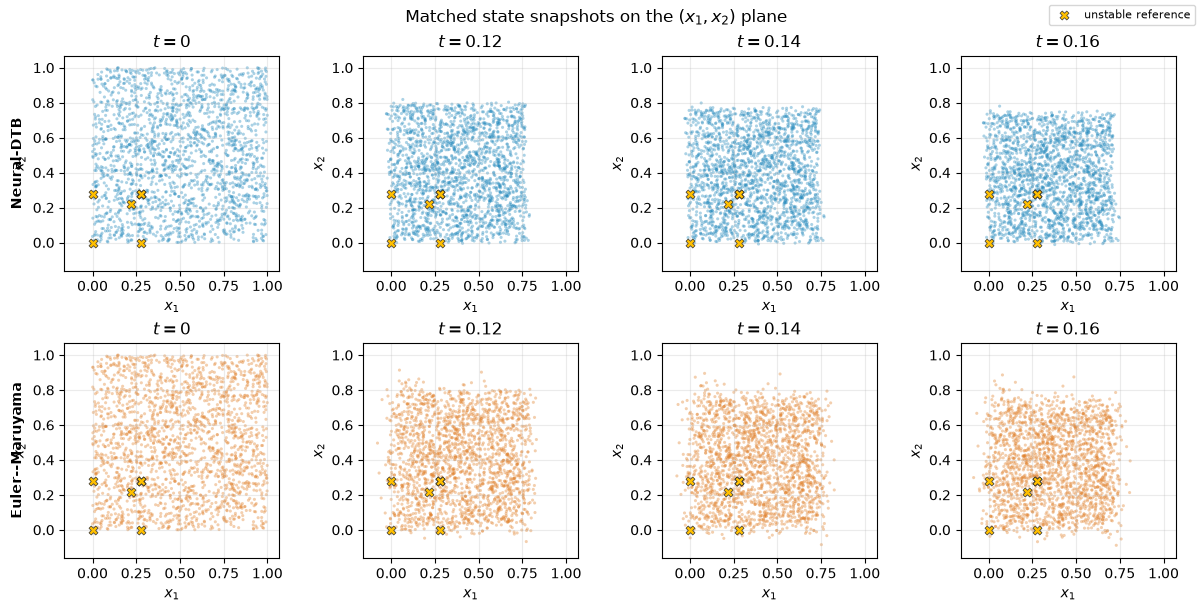

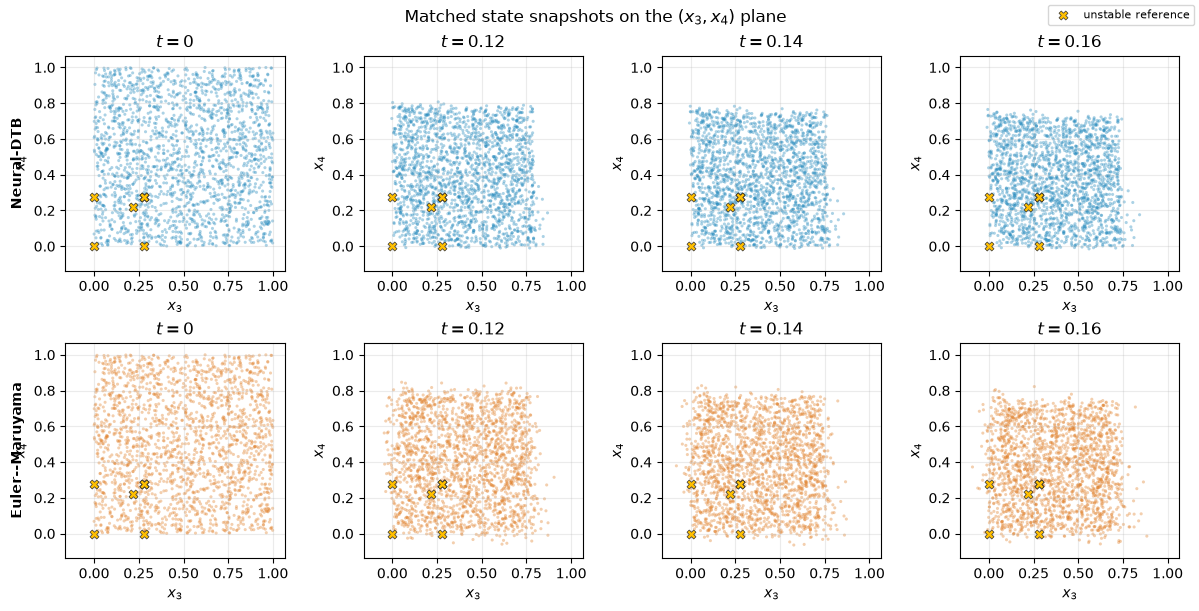

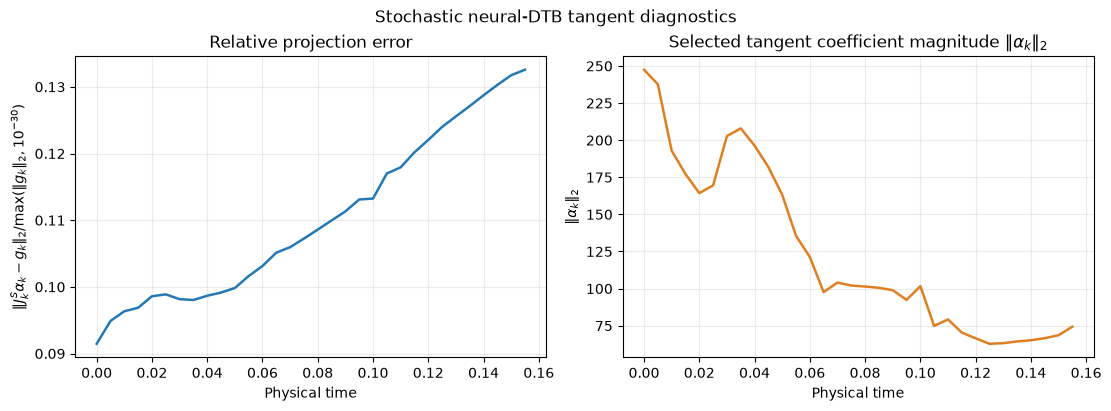

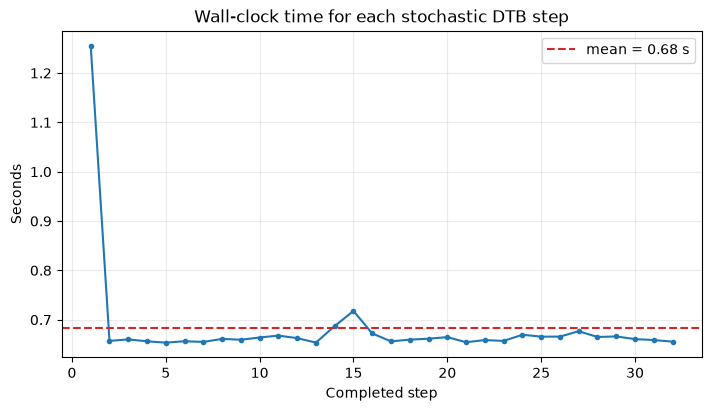

## Stochastic DTB diagnostics

| Metric | Mathematical definition | First | Mean | Final |
| :--- | :--- | ---: | ---: | ---: |
| Relative projection error | $r_k=\frac{\|J_k^S\alpha_k-g_k\|_2}{\max(\|g_k\|_2,10^{-30})}$ | 9.1466e-02 | 1.1023e-01 | 1.3257e-01 |
| Coefficient magnitude | $a_k=\|\alpha_k\|_2$ | 2.4748e+02 | 1.2353e+02 | 7.4329e+01 |
| Score RMS | $s_k=\sqrt{N^{-1}\sum_i\|q_i^k\|_2^2}$ | 0.0000e+00 | 2.2916e-01 | 6.2726e-01 |
| Diffusion correction RMS | $c_k=\frac{1}{2\sqrt N}\|Dq_k\|_2$ | 0.0000e+00 | 1.1458e-03 | 3.1363e-03 |
| Target velocity RMS | $v_k^g=N^{-1/2}\|g_k\|_2$ | 2.5502e+00 | 2.1564e+00 | 1.7968e+00 |
| Tangent velocity RMS | $v_k^u=N^{-1/2}\|u_k\|_2$ | 2.5395e+00 | 2.1434e+00 | 1.7810e+00 |

## Final distribution comparison

| Final DTB versus Euler--Maruyama metric | Value |
| :--- | ---: |
| $\|\bar x_{\mathrm{DTB}}-\bar x_{\mathrm{EM}}\|_2$ | 1.5241e-02 |
| $\|\operatorname{Cov}_{\mathrm{DTB}}-\operatorname{Cov}_{\mathrm{EM}}\|_F$ | 4.1660e-03 |
| Sliced $W_2$ | 9.0415e-03 |

SAVE_RUN=False: results were displayed without creating an output folder.


In [6]:
# BLOCK 4 — Plot matched snapshots, plot tangent diagnostics, and optionally save the run.
output_dir = None
if SAVE_RUN:
    output_dir = create_run_directory(
        EXPERIMENT_DIR / 'saved_runs',
        dim=DIM,
        network=NN_CHOICE,
        activation=NN_ACTIVATION,
        width=MLP_WIDTH,
        depth=MLP_DEPTH,
        parameter_count=N_PARAMETERS,
        basis_size=BASIS_SIZE,
        seed=SEED,
    )
    CONFIG['output_dir'] = str(output_dir)

# Each coordinate plane gets a two-row figure: DTB above and EM below.
snapshot_figures = plot_dtb_em_snapshots(
    dtb_history,
    em_history,
    state_times,
    snapshot_steps,
    coordinate_pairs=COORDINATE_PAIRS,
    equilibria=KNOWN_EQUILIBRIA,
    stable_mask=STABLE_MASK,
    output_dir=output_dir,
)

# Plot exactly the two requested tangent-bundle diagnostics against physical time.
relative_projection_errors = np.asarray([
    record['relative_projection_error'] for record in diagnostic_records
])
alpha_norms = np.asarray([record['alpha_norm'] for record in diagnostic_records])
diagnostics_figure = plot_tangent_diagnostics(
    solve_times,
    relative_projection_errors,
    alpha_norms,
    output_path=None if output_dir is None else output_dir / 'tangent_diagnostics.png',
)


# Plot the measured wall-clock duration of every completed DTB step.
timing_figure, timing_axis = plt.subplots(figsize=(7, 4), constrained_layout=True)
step_numbers = np.arange(1, N_STEPS + 1)
timing_axis.plot(step_numbers, step_seconds_history, marker='o', markersize=3)
timing_axis.axhline(
    step_seconds_history.mean(), color='tab:red', linestyle='--',
    label=f'mean = {step_seconds_history.mean():.2f} s',
)
timing_axis.set(
    title='Wall-clock time for each stochastic DTB step',
    xlabel='Completed step',
    ylabel='Seconds',
)
timing_axis.grid(alpha=.25)
timing_axis.legend()
if output_dir is not None:
    timing_figure.savefig(output_dir / 'step_timing.png', dpi=180, bbox_inches='tight')
plt.show()

# Display the diagnostic definitions and their first, mean, and final values in math.
metric_table = diagnostics_markdown(diagnostic_records)
display(Markdown('## Stochastic DTB diagnostics'))
display(Markdown(metric_table))

# Compare final point-cloud location and spread without reducing dimension by PCA.
final_mean_gap = np.linalg.norm(dtb_history[-1].mean(axis=0) - em_history[-1].mean(axis=0))
final_covariance_gap = np.linalg.norm(
    np.cov(dtb_history[-1], rowvar=False) - np.cov(em_history[-1], rowvar=False)
)
final_sliced_wasserstein = sliced_wasserstein_distance(
    dtb_history[-1], em_history[-1], seed=SEED
)
comparison_table = '\n'.join([
    '| Final DTB versus Euler--Maruyama metric | Value |',
    '| :--- | ---: |',
    rf'| $\|\bar x_{{\mathrm{{DTB}}}}-\bar x_{{\mathrm{{EM}}}}\|_2$ | {final_mean_gap:.4e} |',
    rf'| $\|\operatorname{{Cov}}_{{\mathrm{{DTB}}}}-\operatorname{{Cov}}_{{\mathrm{{EM}}}}\|_F$ | {final_covariance_gap:.4e} |',
    f'| Sliced $W_2$ | {final_sliced_wasserstein:.4e} |',
])
display(Markdown('## Final distribution comparison'))
display(Markdown(comparison_table))

# SAVE_RUN=False leaves the repository unchanged and only displays results.
if output_dir is not None:
    save_run_data(
        output_dir,
        config=CONFIG,
        arrays={
            'times': state_times,
            'solve_times': solve_times,
            'dtb_particles': dtb_history,
            'reference_labels': z.detach().cpu().numpy(),
            'theta_initial': theta_0.detach().cpu().numpy(),
            'theta_final': theta_final.detach().cpu().numpy(),
            'scores': score_history,
            'log_density': log_density_history,
            'em_particles': em_history,
            'coefficients': coefficient_history,
            'selected_parameter_indices': selected.detach().cpu().numpy(),
            'relative_projection_error': relative_projection_errors,
            'alpha_norm': alpha_norms,
            'step_seconds': step_seconds_history,
        },
        metrics_markdown=metric_table + '\n\n' + comparison_table,
    )
    print('Saved figures, histories, configuration, and metric tables to:', output_dir)
else:
    print('SAVE_RUN=False: results were displayed without creating an output folder.')